In [30]:
from src.qcd.full_theory.canonical_diagrams import can_points, can_connections, can_count
from src.rendering.matplotlib_backend import *
from src.transforms.concatenation import in_out_connections, rearrange_in_out_points, equalize_x_spacing
from src.search.comparison import group_diagrams
from src.transforms.format import trim_zeros_2D

from src.transforms.concatenation import combine_diagrams_order, make_connection

next_order_points, next_order_connections, next_order_numbers = combine_diagrams_order([can_points[0]], [can_connections[0]], [can_count[0]], typeofproc=[2, 2], max_order=4)
next_order_points, next_order_connections, next_order_numbers = group_diagrams(next_order_points, next_order_connections, next_order_numbers)

#print(f"Number of diagrams at next order: {len(next_order_points)}")

#represent_diagram_as_png(next_order_points[20], next_order_connections[20], 20, colors=['black', 'black', 'blue', 'red'], linestyles=['solid','dotted', 'solid', 'solid'])
"""
for i in range(len(next_order_points)):
    in_out_connections_ = in_out_connections(next_order_connections[i])
    inp = 0
    out = 0
    for j in range(len(next_order_connections[0])):
        inp += len(np.trim_zeros(in_out_connections_[j, 0]))
        out += len(np.trim_zeros(in_out_connections_[j, 1]))
    rearrange_in_out_points(next_order_points[i], next_order_connections[i])
    next_order_points[i]=equalize_x_spacing(next_order_points[i], 2)
    represent_diagram_as_png_feynman(next_order_points[i], next_order_connections[i], i, colors=['black', 'black', 'blue', 'red'], flavour_=['loopy','simple', 'simple', 'simple'])
"""

"\nfor i in range(len(next_order_points)):\n    in_out_connections_ = in_out_connections(next_order_connections[i])\n    inp = 0\n    out = 0\n    for j in range(len(next_order_connections[0])):\n        inp += len(np.trim_zeros(in_out_connections_[j, 0]))\n        out += len(np.trim_zeros(in_out_connections_[j, 1]))\n    rearrange_in_out_points(next_order_points[i], next_order_connections[i])\n    next_order_points[i]=equalize_x_spacing(next_order_points[i], 2)\n    represent_diagram_as_png_feynman(next_order_points[i], next_order_connections[i], i, colors=['black', 'black', 'blue', 'red'], flavour_=['loopy','simple', 'simple', 'simple'])\n"

In [31]:
next_next_order_points, next_next_order_connections, next_next_order_numbers = combine_diagrams_order([can_points[0], next_order_points], [can_connections[0], next_order_connections], [can_count[0], next_order_numbers], typeofproc=[1, 2], max_order=4)
next_next_order_points, next_next_order_connections, next_next_order_numbers = group_diagrams(next_next_order_points, next_next_order_connections, next_next_order_numbers)

print(f"Number of diagrams at next-next order: {len(next_next_order_points)}")

from collections import defaultdict
import numpy as np

def find_loops (points, connections, min_loop_len=3):
    edges = trim_zeros_2D(connections.reshape(-1, 2))
    graph = defaultdict(set)
    for u, v in edges:
        graph[u].add(v)
        graph[v].add(u)

    cycles = set()

    def normalize(cycle):
        cycle = cycle[:-1] if cycle[0] == cycle[-1] else cycle
        n = len(cycle)
        rots = [tuple(cycle[i:] + cycle[:i]) for i in range(n)]
        rev = cycle[::-1]
        rots_rev = [tuple(rev[i:] + rev[:i]) for i in range(n)]
        return min(rots + rots_rev)

    def dfs(start, curr, path, parent):
        for nbr in graph[curr]:
            if nbr == parent:
                continue
            if nbr == start and len(path) >= min_loop_len:
                cycles.add(normalize(path))
            elif nbr not in path:
                dfs(start, nbr, path + [nbr], curr)

    for node in graph:
        dfs(node, node, [node], None)

    loops_ =  [list(c) for c in sorted(cycles)]
    if len(loops_) == 0:
        return
    else:
        max_len = max(len(l) for l in loops_)
        loops = np.full((len(loops_), max_len), 1, dtype=int)
        for i, l in enumerate(loops_):
            loops[i, :len(l)] = l
        loops = loops-1


    def other_index_out_of_loop(edges, loop, node):
        loop = set(loop)

        for a, b in edges:
            if a == node and b not in loop:
                return b
            if b == node and a not in loop:
                return a

        return None

    for loop in loops:
        y_vals = points[loop, 1]
        while np.all(np.isclose(y_vals, y_vals[0])):
            x_pos = points[loop, 0]
            mid_vals = loop[(x_pos > x_pos.min()) & (x_pos < x_pos.max())]
            for idx in mid_vals:
                other_idx = other_index_out_of_loop(edges-1, loop, idx)
                if other_idx is not None and points[idx, 1] != points[other_idx, 1]:
                    points[idx, 1] = points[other_idx, 1]
                else:
                    points[idx, 1] += 1
            y_vals = points[loop, 1]


Number of diagrams at next-next order: 1184


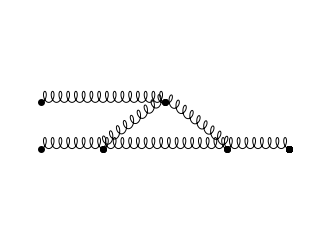

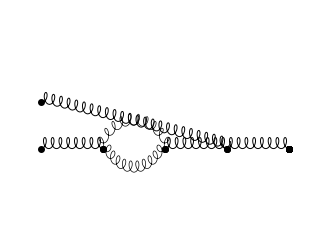

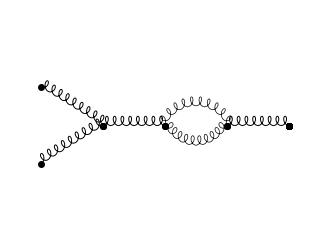

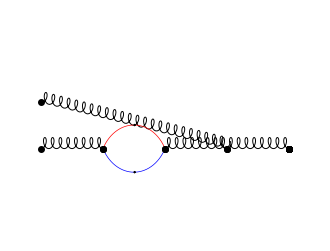

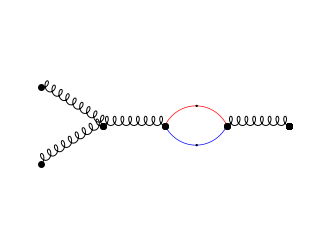

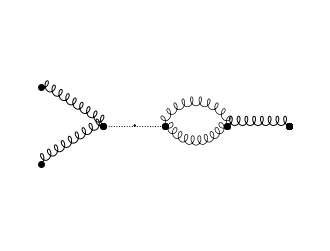

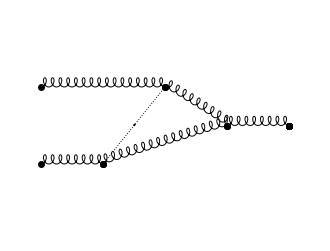

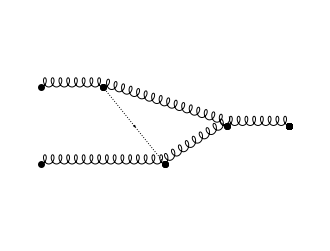

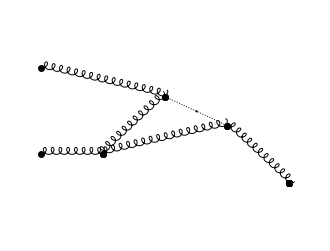

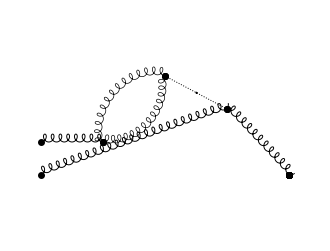

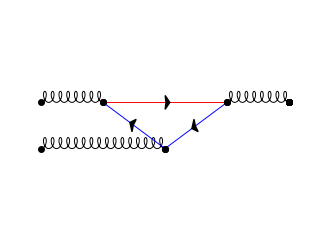

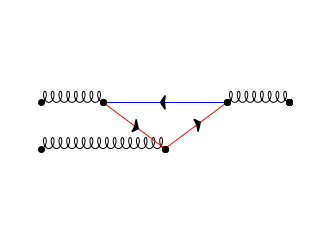

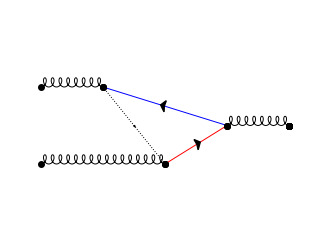

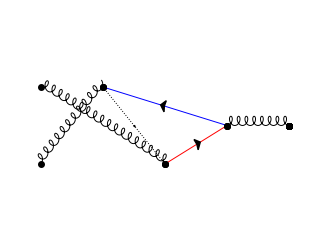

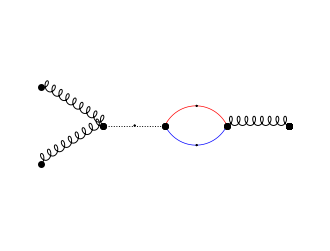

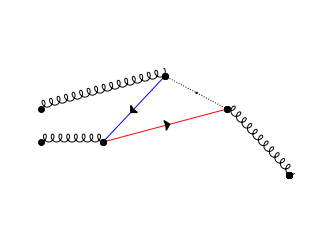

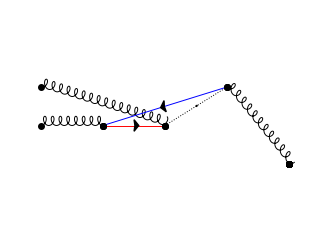

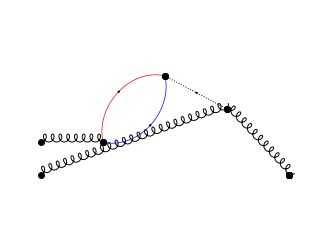

In [32]:
for i in range(len(next_next_order_points)):
    in_out_connections_ = in_out_connections(next_next_order_connections[i])
    inp_g = len(np.trim_zeros(in_out_connections_[0, 0]))
    out_g = len(np.trim_zeros(in_out_connections_[0, 1]))
    inp = 0
    out = 0
    for j in range(1, len(next_next_order_connections[i])):
        inp += len(np.trim_zeros(in_out_connections_[j, 0]))
        out += len(np.trim_zeros(in_out_connections_[j, 1]))
    if inp == 0 and out == 0 and inp_g == 1 and out_g == 2:
        rearrange_in_out_points(next_next_order_points[i], next_next_order_connections[i])
        next_next_order_points[i]=equalize_x_spacing(next_next_order_points[i], 2)
        find_loops(next_next_order_points[i], next_next_order_connections[i])
        represent_diagram_as_png_feynman(next_next_order_points[i], next_next_order_connections[i],i, colors=['black', 'black', 'blue', 'red'], flavour_=['loopy','simple', 'simple', 'simple'])

In [33]:
fourth_order_points, fourth_order_connections, fourth_order_numbers = combine_diagrams_order([can_points[0], next_order_points, next_next_order_points], [can_connections[0], next_order_connections, next_next_order_connections], [can_count[0], next_order_numbers, next_next_order_numbers], typeofproc=[2, 2], max_order=5)
fourth_order_points, fourth_order_connections, fourth_order_numbers = group_diagrams(fourth_order_points, fourth_order_connections, fourth_order_numbers)
print(f"Number of diagrams at fourth order: {len(fourth_order_points)}")

Number of diagrams at fourth order: 18105


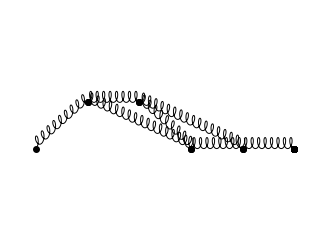

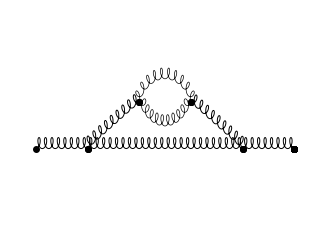

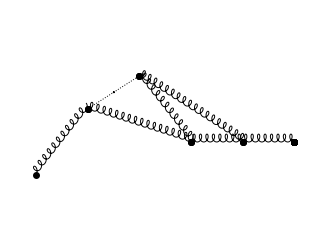

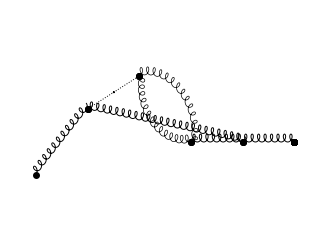

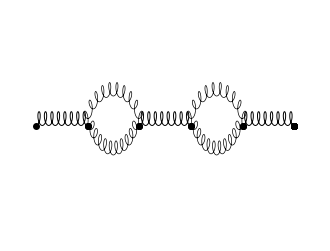

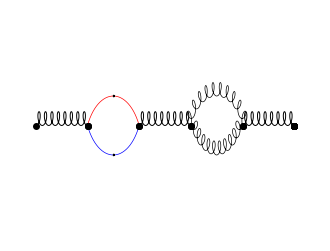

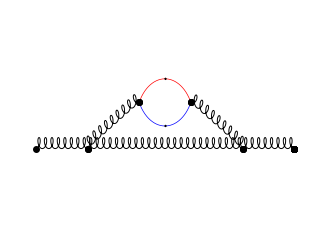

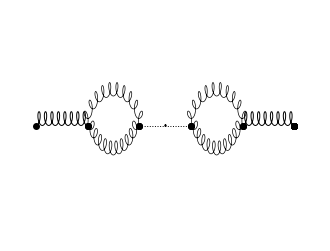

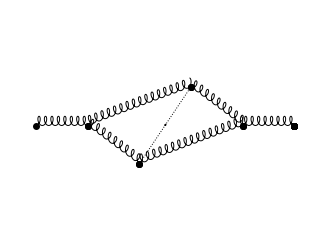

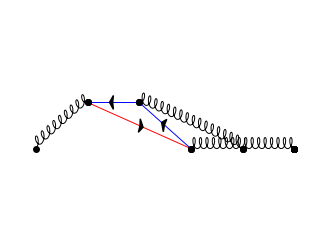

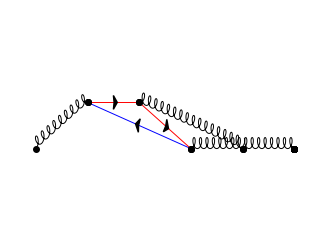

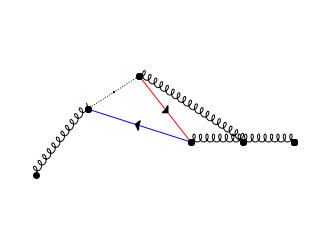

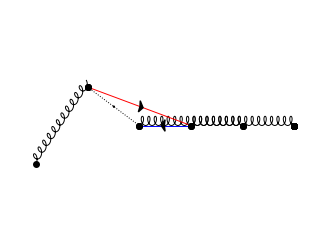

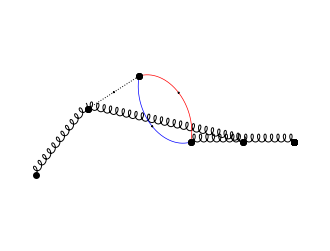

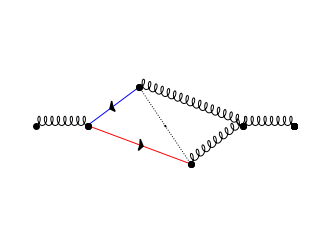

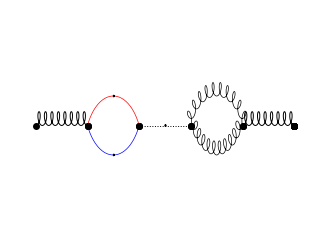

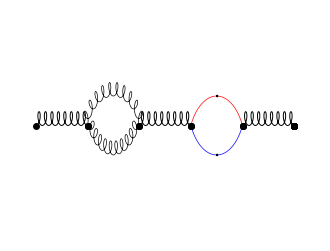

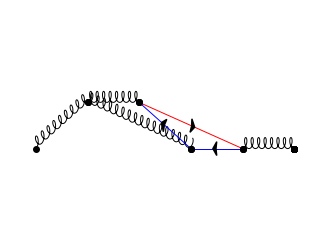

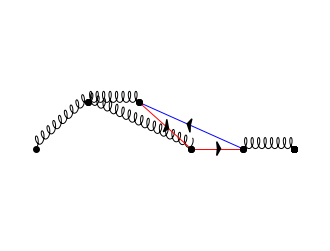

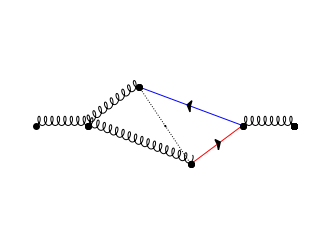

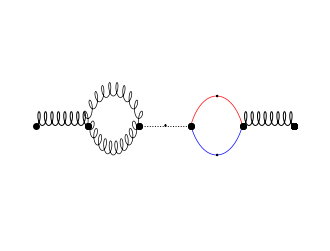

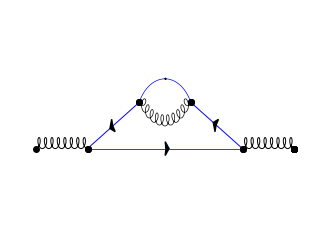

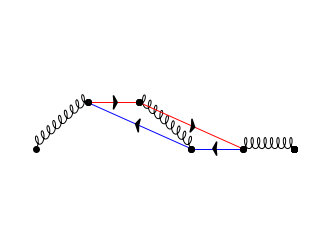

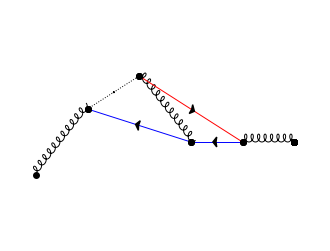

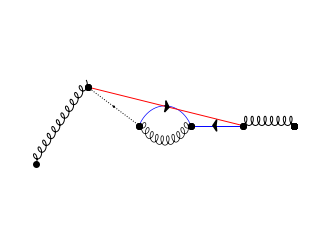

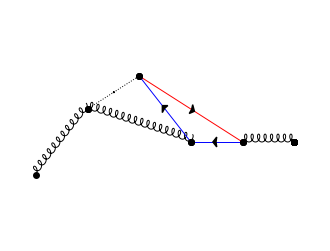

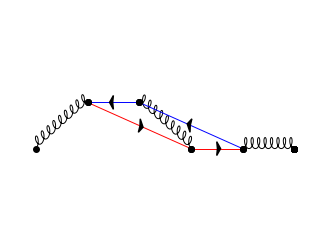

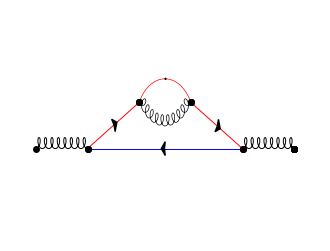

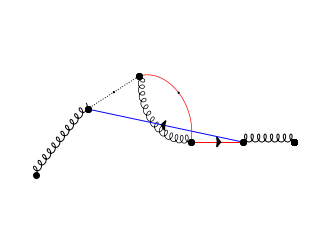

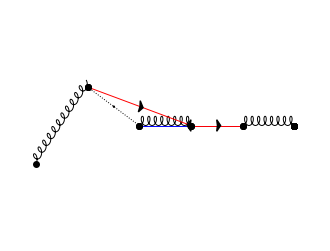

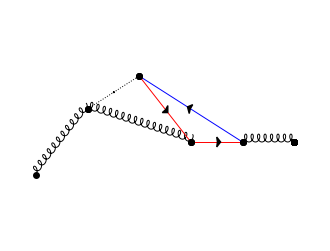

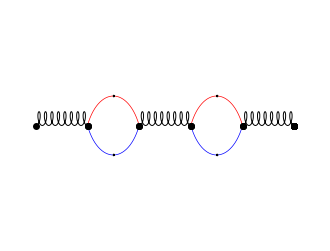

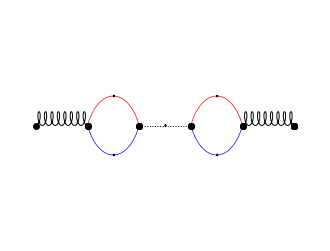

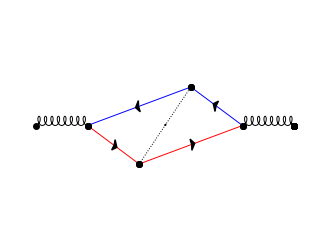

In [34]:
for i in range(len(fourth_order_points)):
    in_out_connections_ = in_out_connections(fourth_order_connections[i])
    inp_g = len(np.trim_zeros(in_out_connections_[0, 0]))
    out_g = len(np.trim_zeros(in_out_connections_[0, 1]))
    inp = 0
    out = 0
    for j in range(1, len(fourth_order_connections[i])):
        inp += len(np.trim_zeros(in_out_connections_[j, 0]))
        out += len(np.trim_zeros(in_out_connections_[j, 1]))
    if inp == 0 and out == 0 and inp_g == 1 and out_g == 1:
        rearrange_in_out_points(fourth_order_points[i], fourth_order_connections[i])
        fourth_order_points[i]=equalize_x_spacing(fourth_order_points[i], 2)
        find_loops(fourth_order_points[i], fourth_order_connections[i])
        represent_diagram_as_png_feynman(fourth_order_points[i], fourth_order_connections[i], i, colors=['black', 'black', 'blue', 'red'], flavour_=['loopy','simple', 'simple', 'simple'])